In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
import tensorflow as tf
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential    
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.optimizers import Adam


In [2]:
DATASET_PATH = r"C:\Users\bhagi\Documents\Sign Language\train\asl_alphabet_train"


In [3]:
IMG_SIZE = (64, 64)  # Increased from 64x64 for better feature extraction
BATCH_SIZE = 64
EPOCHS = 25  # Increased epochs with early stopping
INITIAL_LEARNING_RATE = 0.001


In [4]:
# Optional: Advanced preprocessing function for image enhancement
# This can be used with a custom data generator if needed
def preprocess_image(img):
    """
    Advanced preprocessing function
    Can be used with custom data generator for additional preprocessing
    """
    import cv2
    
    # Convert to numpy array if needed
    if isinstance(img, tf.Tensor):
        img = img.numpy()
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for better contrast
    # This helps with varying lighting conditions
    if len(img.shape) == 3:
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        img = cv2.merge([l, a, b])
        img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
    
    return img

# Note: The ImageDataGenerator handles basic preprocessing
# For advanced preprocessing, you can create a custom generator
# For now, we'll use the built-in augmentation which is sufficient

In [5]:
# Comprehensive data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,           # Rotate images up to 20 degrees
    width_shift_range=0.2,       # Shift horizontally by 20%
    height_shift_range=0.2,      # Shift vertically by 20%
    shear_range=0.15,            # Apply shear transformation
    zoom_range=0.15,             # Zoom in/out by 15%
    horizontal_flip=False,       # Don't flip (sign language is directional)
    fill_mode='nearest',         # Fill pixels with nearest value
    brightness_range=[0.8, 1.2], # Adjust brightness
    channel_shift_range=0.1      # Shift color channels
)

# Only rescale for validation (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)


Found 62400 images belonging to 26 classes.
Found 15600 images belonging to 26 classes.


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))
base_model.trainable = False  # freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [7]:
# Enhanced CNN model with better architecture
cnn_model = Sequential([
    Input(shape=(*IMG_SIZE, 3)),
    
    # First block - 32 filters
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Second block - 64 filters
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Third block - 128 filters
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Fourth block - 256 filters
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Fifth block - 512 filters (additional depth)
    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    # Fully connected layers
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])


In [8]:
# Learning rate schedule function
def lr_schedule(epoch):
    """Learning rate schedule - reduce LR by 10x at epochs 15, 30, 45"""
    initial_lr = INITIAL_LEARNING_RATE
    if epoch < 15:
        return initial_lr
    elif epoch < 30:
        return initial_lr * 0.1
    elif epoch < 45:
        return initial_lr * 0.01
    else:
        return initial_lr * 0.001

# Compile with optimized settings
optimizer = Adam(learning_rate=INITIAL_LEARNING_RATE, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy',TopKCategoricalAccuracy(k=3, name='top_3_accuracy')
])

# Display model summary
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,548,474 (13.54 MB)

 Trainable params: 3,543,994 (13.52 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [9]:
# Callbacks for better training
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,  # Stop if no improvement for 10 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=r"C:\Users\bhagi\Documents\Sign Language\best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    LearningRateScheduler(lr_schedule, verbose=1)
]

# Train the model
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


C:\Users\bhagi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1711 - loss: 3.4918 - top_3_accuracy: 0.3460   
Epoch 1: val_accuracy improved from None to 0.39603, saving model to C:\Users\bhagi\Documents\Sign Language\best_model.keras
975/975 ━━━━━━━━━━━━━━━━━━━━ 1564s 2s/step - accuracy: 0.3501 - loss: 2.5242 - top_3_accuracy: 0.5809 - val_accuracy: 0.3960 - val_loss: 2.4808 - val_top_3_accuracy: 0.6972 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/25
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7826 - loss: 0.9177 - top_3_accuracy: 0.9537   
Epoch 2: val_accuracy improved from 0.39603 to 0.81083, saving model to C:\Users\bhagi\Documents\Sign Language\best_model.keras
975/975 ━━━━━━━━━━━━━━━━━━━━ 1563s 2s/step - accuracy: 0.8307 - loss: 0.7868 - top_3_accuracy: 0.9679 - val_accuracy: 0.8108 - val_loss: 1.0027 - val_top_3_accuracy: 0.9335 - learning_rate: 0.0010

C:\Users\bhagi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1950/1950 ━━━━━━━━━━━━━━━━━━━━ 749s 382ms/step - accuracy: 0.5657 - loss: 1.3563 - val_accuracy: 0.7611 - val_loss: 0.6779
Epoch 2/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 768s 394ms/step - accuracy: 0.9271 - loss: 0.2188 - val_accuracy: 0.8469 - val_loss: 0.5557
Epoch 3/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 586s 300ms/step - accuracy: 0.9646 - loss: 0.1179 - val_accuracy: 0.8047 - val_loss: 1.0606
Epoch 4/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 726s 372ms/step - accuracy: 0.9781 - loss: 0.0785 - val_accuracy: 0.7152 - val_loss: 1.3921
Epoch 5/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 544s 279ms/step - accuracy: 0.9830 - loss: 0.0667 - val_accuracy: 0.8453 - val_loss: 0.8876
Epoch 6/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 539s 276ms/step - accuracy: 0.9855 - loss: 0.0612 - val_accuracy: 0.8140 - val_loss: 1.0955
Epoch 7/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 537s 275ms/step - accuracy: 0.9886 - loss: 0.0495 - val_accuracy: 0.7253 - val_loss: 1.6366
Epoch 8/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 559s 287ms/step - accuracy: 0.9

In [12]:
# Evaluate on validation data
val_results = cnn_model.evaluate(val_data)

# Print all validation metrics properly
print("Validation Results:")
for name, value in zip(cnn_model.metrics_names, val_results):
    print(f"{name}: {value}")

# Get final training accuracy from history
train_acc = history.history['accuracy'][-1]
print("Final Training Accuracy:", train_acc)

244/244 ━━━━━━━━━━━━━━━━━━━━ 74s 302ms/step - accuracy: 0.9800 - loss: 0.4098 - top_3_accuracy: 0.9982
Validation Results:
loss: 0.40984684228897095
compile_metrics: 0.9800000190734863
Final Training Accuracy: 0.9945993423461914


244/244 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step


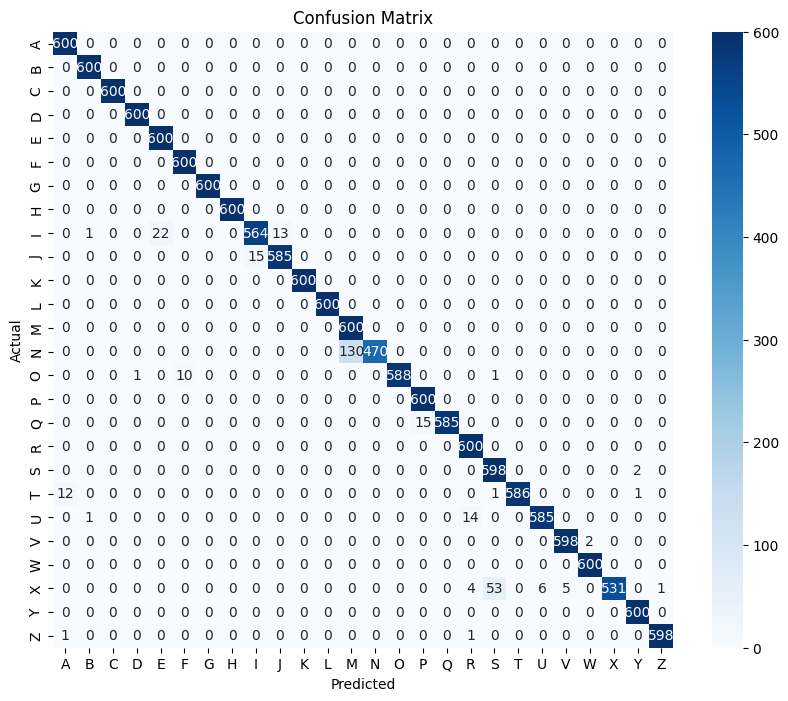

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get true labels
y_true = val_data.classes

# Get predictions
y_pred_probs = cnn_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

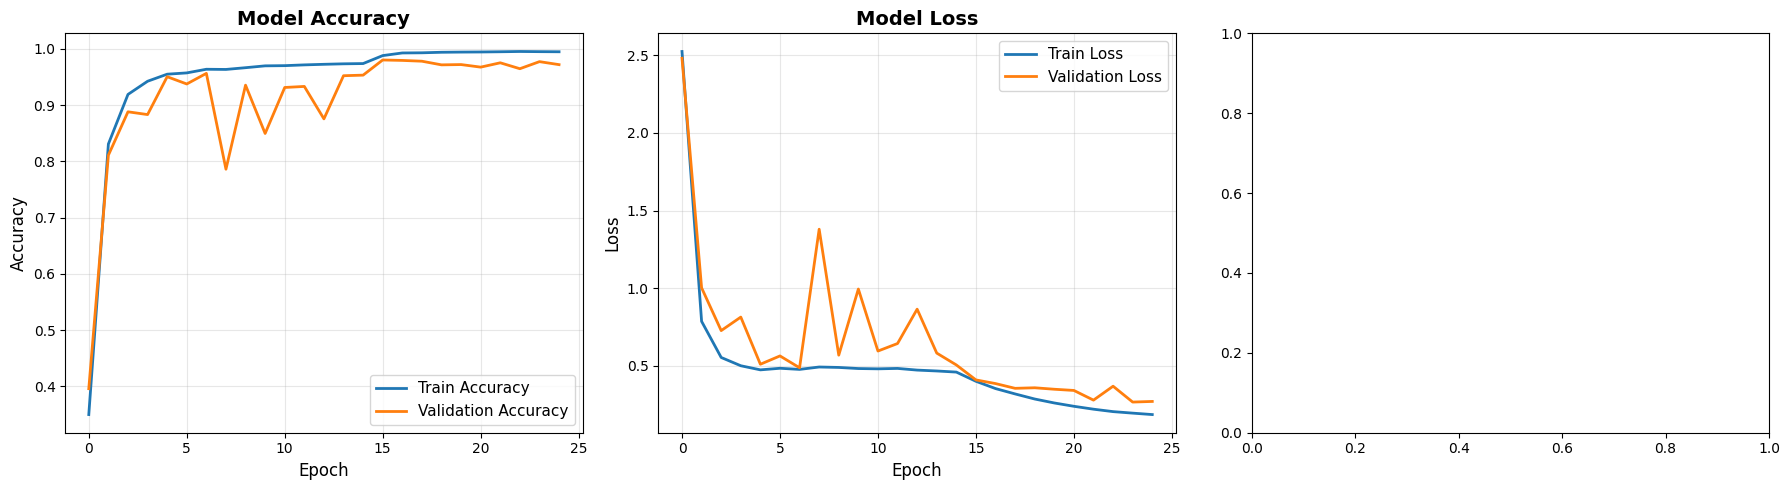


Best Validation Accuracy: 0.9800 at Epoch 16


In [15]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Learning rate plot
if 'lr' in history.history:
    axes[2].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='green')
    axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Learning Rate', fontsize=12)
    axes[2].set_yscale('log')
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best validation accuracy
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at Epoch {best_epoch}")


In [ ]:
import joblib

# Load the best model if it exists
best_model_path = r"C:\Users\bhagi\Documents\Sign Language\best_model.keras"
if os.path.exists(best_model_path):
    print("Loading best model from checkpoint...")
    cnn_model = tf.keras.models.load_model(best_model_path)
    print("Best model loaded successfully!")

# Save the final model in the recommended Keras format
cnn_model.save(r"C:\Users\bhagi\Documents\Sign Language\sign_language_model_improved.keras")

# Save the class labels
joblib.dump(
    list(train_data.class_indices.keys()),
    r"C:\Users\bhagi\Documents\Sign Language\class_labels.pkl"
)

# Also save into GestureLab models/ so the Practice page finds them (when notebook is run from project)
GESTURELAB_MODELS = os.path.join(os.getcwd(), "models")
if os.path.isdir("app") or os.path.isfile("using cnn.ipynb"):
    os.makedirs(GESTURELAB_MODELS, exist_ok=True)
    cnn_model.save(os.path.join(GESTURELAB_MODELS, "sign_language_model_improved.keras"))
    joblib.dump(list(train_data.class_indices.keys()), os.path.join(GESTURELAB_MODELS, "class_labels.pkl"))
    print("Also saved to GestureLab models/ for the Practice page.")

print("\nModel and class labels saved successfully!")
print(f"Final model saved as: sign_language")

Loading best model from checkpoint...
Best model loaded successfully!

Model and class labels saved successfully!
Final model saved as: sign_language


In [ ]:
# Copy model and labels into GestureLab so the Practice page can use them.
# Run this cell after training (or when you already have the files in "Sign Language" folder).
import os
import shutil

# Where your notebook saved the model (same as in the save cell above)
SIGN_LANG_DIR = r"C:\Users\bhagi\Documents\Sign Language"
SRC_MODEL = os.path.join(SIGN_LANG_DIR, "sign_language_model_improved.keras")
SRC_LABELS = os.path.join(SIGN_LANG_DIR, "class_labels.pkl")

# GestureLab project: assume notebook is inside the project (e.g. GestureLab-main/using cnn.ipynb)
GESTURELAB_ROOT = os.getcwd()
if not os.path.isfile("using cnn.ipynb") and not os.path.isdir("app"):
    GESTURELAB_ROOT = os.path.dirname(os.getcwd())
MODELS_DIR = os.path.join(GESTURELAB_ROOT, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
DST_MODEL = os.path.join(MODELS_DIR, "sign_language_model_improved.keras")
DST_LABELS = os.path.join(MODELS_DIR, "class_labels.pkl")

if os.path.isfile(SRC_MODEL):
    shutil.copy2(SRC_MODEL, DST_MODEL)
    print(f"Copied model to {DST_MODEL}")
else:
    if "cnn_model" in dir() and cnn_model is not None:
        cnn_model.save(DST_MODEL)
        print(f"Saved model to {DST_MODEL}")
    else:
        print("Model not found at", SRC_MODEL, "- run the save cell above first, then run this again.")

if os.path.isfile(SRC_LABELS):
    shutil.copy2(SRC_LABELS, DST_LABELS)
    print(f"Copied class_labels.pkl to {DST_LABELS}")
else:
    if "train_data" in dir() and train_data is not None:
        import joblib
        joblib.dump(list(train_data.class_indices.keys()), DST_LABELS)
        print(f"Saved class_labels.pkl to {DST_LABELS}")
    else:
        print("class_labels.pkl not found at", SRC_LABELS, "- run the save cell above first.")

Copied model to C:\Users\bhagi\Documents\Sign Language\models\sign_language_model_improved.keras
Copied class_labels.pkl to C:\Users\bhagi\Documents\Sign Language\models\class_labels.pkl
